# Summarisation with T-5

**Connect to a GPU runtime environment if you have access to one (Runtime -> Change runtime type).**


In this notebook, we will see how to fine-tune one of the [HuggingFace Transformers](https://github.com/huggingface/transformers) model (T5) for the summarisation task. We will use the [Pubmed Summarization](https://aclanthology.org/N18-2097.pdf) data (for extreme summarisation) which contains research papers and their abstracts.

[T5](https://paperswithcode.com/method/t5) is a popular model, which is designed as a text-to-text multi-task model. For each task, both input and output is text (so that for a regression task, a number 2.5 becomes a string "2.5"). Hence we can use the same model for a range of tasks including translation, linguistic acceptability, sentence similarity, document summarisation (our case), etc.

We will start by installing 🤗 Huggingface Transformers and 🤗 Huggingface Datasets as well as other dependencies.

Much of our code is based on the [official tutorial](https://github.com/huggingface/notebooks/blob/main/examples/summarization.ipynb).

In [32]:
! pip install transformers datasets
! pip install rouge-score nltk evaluate

## Loading the Dataset




We will use the [HuggingFace Datasets](https://github.com/huggingface/datasets) library to download the data. This a very good resource for easy manipulation of commonly used datasets.

In [33]:
from datasets import load_dataset

# If the training time is too much and you do not have GPU then uncomment the below line and re-run the notebook
# Note that here we are reducing the size of the dataset hence the values are going to be different to what you will see when you run it on full dataset
original_datasets = load_dataset("ccdv/pubmed-summarization", split="validation[:2%]")
# original_datasets = load_dataset("ccdv/pubmed-summarization", split="validation[:50%]")

We will further create a train and a validation set by splitting the original validation set.

In [34]:
import datasets as ds

# We will use only the validation set due to the lack of computational resources
# Split the initial validation set
train_valid = original_datasets.train_test_split(test_size=0.25)

# Gather the sets into a single DatasetDict
raw_datasets = ds.DatasetDict({'train': train_valid['train'], 'validation': train_valid['test']})

In [35]:
print(raw_datasets["train"][0])

{'article': "strict control of diabetes is increasingly emphasized after the benefits demonstrated in the uk prospective diabetes study and dcct studies . \n hypoglycemia tops the list of hurdles in preventing tight glycemic control and is often observed in patients on insulin or insulin secretagogue ( like sulfonylurea ) therapies . \n recent studies have demonstrated that though strict glycemic control results in reduced microvascular complications , it is associated with increased cardiovascular events and even mortality ( accord ) . the likely explanation proposed for the latter observation is hypoglycemia and its adverse effect on the cardiovascular system through the sympathoadrenal responses . \n hence , the american diabetic association ( ada ) , aace , and other guidelines recommend not to be too strict with glycemic control , especially in the elderly or patients with long duration of diabetes and with other significant comorbidities . \n hypoglycemic episodes , especially if

### Some Data Analysis

Here we will perform some basic exploratory data analysis by computing the mean and standard deviation of token counts for the source and target documents.

The `show_random_elements` method below displays a table containing `num_examples` samples from the specified `dataset`, with fields `article`, `abstract` and `id`

**Task 1: Summarisation data statistics**

Complete the functions below by tokenising the documents (the best option would be to use the tokeniser but here you can just split on spaces) and print the mean token count and standard deviation for source and target documents for each dataset. Plot histograms of the source and target token counts (method `show_token_counts` is provided). Comment on the lengths of input and target texts for summarisation.



train Articles
Mean tokens: 3022.09	Std tokens: 1934.51


train Abstracts
Mean tokens: 194.05	Std tokens: 82.02


validation Articles
Mean tokens: 2637.26	Std tokens: 1463.39


validation Abstracts
Mean tokens: 190.97	Std tokens: 76.57


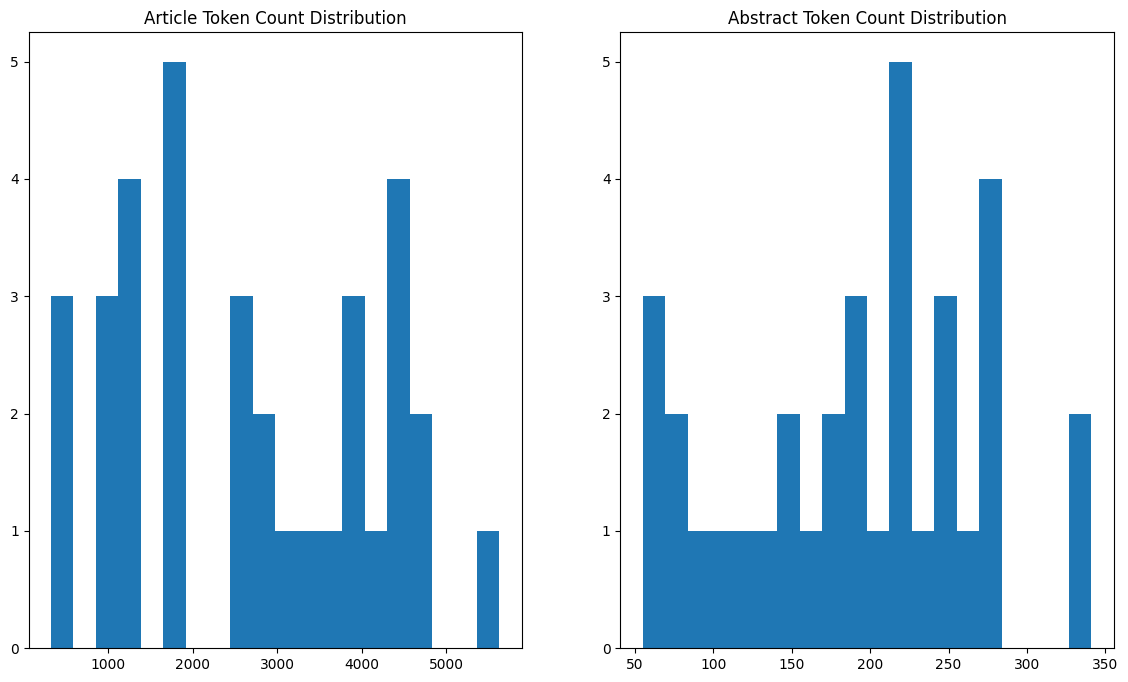

In [36]:
import datasets
import random
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt

def show_random_elements(dataset, num_examples=5):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)

    df = pd.DataFrame(dataset[picks])
    for column, typ in dataset.features.items():
        if isinstance(typ, datasets.ClassLabel):
            df[column] = df[column].transform(lambda i: typ.names[i])
    display(HTML(df.to_html()))


def calculate_token_counts(dataset):
    # TO DO
    source_counts = [len(x.split()) for x in dataset['article']]
    target_counts = [len(x.split()) for x in dataset['abstract']]
    return source_counts, target_counts
    # TO DO

def token_counts_summary(raw_datasets):
     # TO DO
    for name, dataset in raw_datasets.items():
        source_counts, target_counts = calculate_token_counts(dataset)

        mean_src_count = np.mean(source_counts)
        std_src_count = np.std(source_counts)
        print('\n')
        print(name + ' Articles')
        print(f'Mean tokens: {mean_src_count:.2f}\tStd tokens: {std_src_count:.2f}')

        mean_tgt_count = np.mean(target_counts)
        std_tgt_count = np.std(target_counts)
        print('\n')
        print(name + ' Abstracts')
        print(f'Mean tokens: {mean_tgt_count:.2f}\tStd tokens: {std_tgt_count:.2f}')
      # TO DO

def show_token_counts(dataset):
    source_counts, target_counts = calculate_token_counts(dataset)
    f, (ax0, ax1) = plt.subplots(1, 2, figsize=(14, 8))
    ax0.hist(source_counts, bins=20)
    ax1.hist(target_counts, bins=20)
    ax0.set_title("Article Token Count Distribution")
    ax1.set_title("Abstract Token Count Distribution")

show_random_elements(raw_datasets["validation"])
show_token_counts(raw_datasets["validation"])
token_counts_summary(raw_datasets)

### ROUGE Metric

To evaluate our model's performance, we will use **ROUGE (Recall-Oriented Understudy for Gisting Evaluation)**. It compares n-grams of the model outputs to reference text and is based on recall.

ROUGE outputs multiple types of scores. ROUGE-N measures the overlap of n-grams between generated and reference summaries, with ROUGE-1 focusing on unigrams and ROUGE-2 on bigrams. ROUGE-L evaluates the longest common subsequence by identifying the longest co-occurring sequences of n-grams. ROUGE-Lsum focuses on the longest common subsequence at the summary level.

You can call its `compute` method with your hypotheses and target summaries, which need to be list of decoded strings:

In [37]:
import evaluate
metric = evaluate.load("rouge", trust_remote_code=True)

# help(metric)      # << Uncomment to see more about the ROUGE eval metric

predicted_summaries = ["AI applications span diverse fields.", "Enhancing efficiency, decision-making, experiences with AI."]
target_doc = 'As artificial intelligence continues to advance, researchers are exploring its applications in diverse fields such as healthcare, finance, education, and entertainment, aiming to improve efficiency, decision-making processes, and overall human experiences.'
docs = [target_doc, target_doc]

metric.compute(predictions=predicted_summaries, references=docs)

{'rouge1': np.float64(0.18364518364518362),
 'rouge2': np.float64(0.08262548262548262),
 'rougeL': np.float64(0.18364518364518362),
 'rougeLsum': np.float64(0.18364518364518362)}

## Preprocessing the Data

We will proprocess the data using the Huggingface `Tokenizer` paired with T5, which tokenises input text and adds additional required tokens. This ensures that our inputs are correctly aligned with the model's embedding matrix.

In [38]:
from transformers import AutoTokenizer

model_checkpoint = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

### Using the Tokenizer

`Tokenizer` outputs are different for different tokenisers. Compare outputs below for the T5 and BERT tokenisers.


In [39]:
print(tokenizer("AI applications span diverse fields."))

tokenizer_ = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer_('AI applications span diverse fields.')

{'input_ids': [7833, 1564, 8438, 2399, 4120, 5, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


{'input_ids': [101, 9932, 5097, 8487, 7578, 4249, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

As we mentioned above, T5 was trained in a multitask setup such that it can perform multiple tasks. We prefix the inputs with "summarize: " to prompt the model to summarise.

We will now create a function to preprocess our samples, feeding them to the tokeniser with the `truncation=True` argument. This ensures that any input exceeding the model's maximum accepted length will be truncated accordingly. Padding will be addressed later in a data collator, allowing us to pad examples to the longest length in the batch rather than the entire dataset.

Complete the `preprocess_function` below to prepare our training data (**Hint**: do not forget to prefix the inputs).

In [40]:
if model_checkpoint in ["t5-small", "t5-base", "t5-large", "t5-3b", "t5-11b"]:
    prefix = "summarize: "
else:
    prefix = ""

In [41]:
max_doc_len = 1024
max_sum_length = 128


def preprocess_samples(samples):

    inputs = list()

    # TO DO
    inputs = [prefix + doc for doc in samples["article"]]
    model_inputs = tokenizer(inputs, max_length=max_doc_len, truncation=True)
    # TO DO
    targets = tokenizer(text_target = samples["abstract"], max_length=max_sum_length, truncation=True)
    model_inputs["labels"] = targets["input_ids"]

    return model_inputs

This function works with one or several examples. In the case of several examples, the tokeniser will return a list of lists for each key:

In [42]:
raw_datasets["train"][:2]

{'article': ["strict control of diabetes is increasingly emphasized after the benefits demonstrated in the uk prospective diabetes study and dcct studies . \n hypoglycemia tops the list of hurdles in preventing tight glycemic control and is often observed in patients on insulin or insulin secretagogue ( like sulfonylurea ) therapies . \n recent studies have demonstrated that though strict glycemic control results in reduced microvascular complications , it is associated with increased cardiovascular events and even mortality ( accord ) . the likely explanation proposed for the latter observation is hypoglycemia and its adverse effect on the cardiovascular system through the sympathoadrenal responses . \n hence , the american diabetic association ( ada ) , aace , and other guidelines recommend not to be too strict with glycemic control , especially in the elderly or patients with long duration of diabetes and with other significant comorbidities . \n hypoglycemic episodes , especially i

In [43]:
preprocess_samples(raw_datasets["train"][:2])

{'input_ids': [[21603, 10, 6926, 610, 13, 8363, 19, 5684, 3, 25472, 227, 8, 1393, 9028, 16, 8, 3, 1598, 11735, 8363, 810, 11, 3, 26, 75, 75, 17, 2116, 3, 5, 10950, 122, 120, 75, 11658, 420, 7, 8, 570, 13, 23463, 7, 16, 3, 13494, 4095, 3, 122, 120, 565, 3113, 610, 11, 19, 557, 6970, 16, 1221, 30, 16681, 42, 16681, 2829, 9, 122, 12220, 41, 114, 3, 7, 83, 89, 106, 63, 40, 1462, 9, 3, 61, 19571, 3, 5, 1100, 2116, 43, 9028, 24, 713, 6926, 3, 122, 120, 565, 3113, 610, 772, 16, 3915, 2179, 15100, 14497, 3, 6, 34, 19, 1968, 28, 1936, 16712, 984, 11, 237, 20544, 41, 4408, 3, 61, 3, 5, 8, 952, 7295, 4382, 21, 8, 7722, 12556, 19, 10950, 122, 120, 75, 11658, 11, 165, 11233, 1504, 30, 8, 16712, 358, 190, 8, 17024, 189, 32, 9, 26, 1536, 138, 7216, 3, 5, 10321, 3, 6, 8, 10211, 17496, 447, 6028, 41, 3, 9, 26, 9, 3, 61, 3, 6, 3, 9, 3302, 3, 6, 11, 119, 5749, 1568, 59, 12, 36, 396, 6926, 28, 3, 122, 120, 565, 3113, 610, 3, 6, 902, 16, 8, 12766, 42, 1221, 28, 307, 8659, 13, 8363, 11, 28, 119, 1516, 3, 28

We will apply the `map` method of our `raw_datasets` object we created earlier. This will apply the function on all the elements of all the splits in `dataset`, so our training, validation and testing data will be preprocessed in one single command.

In [44]:
preprocessed_datasets = raw_datasets.map(preprocess_samples, batched=True)

Map:   0%|          | 0/99 [00:00<?, ? examples/s]

Map:   0%|          | 0/34 [00:00<?, ? examples/s]

The outcomes are automatically stored in the 🤗 Datasets library's cache, so that processing does not need to be repeated. If you need to reapply preprocessing, you can include `load_from_cache_file=False` in the map function call.

We specified `batched=True `to encode texts in batches which employs multi-threading.

## Fine-tuning T5

We will now download the pretrained model and fine-tune it. Since our task is sequence-to-sequence, we use the `AutoModelForSeq2SeqLM` class.

In [45]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [46]:
from transformers import AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Seq2SeqTrainingArguments, Seq2SeqTrainer

model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint, use_cache=False).to(device)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Unlike in our classification task in the first practical, there's no warning here. This indicates that no randomly initialized layers were added.

Now we need to define `Seq2SeqTrainingArguments`. It requires a directory name for saving model checkpoints. We set the learning rate, `batch_size` and customise the weight decay. Setting `predict_with_generate=True` makes the model use the `generate()` method to produce output sequences. Set `push_to_hub=False` to prevent uploading the model to HuggingFace and keep it local. `report_to="none"` disables logging to external tools like Weights & Biases or TensorBoard.

In [47]:
batch_size = 8
model_name = model_checkpoint.split("/")[-1]
args = Seq2SeqTrainingArguments(
    f"{model_name}-pubmed-sum",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    num_train_epochs=1,
    predict_with_generate=True,
    generation_max_length=max_sum_length,
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
    report_to="none",
    save_total_limit=3
)

We need a data collator that not only pads the input sequences to match the longest one in the batch, but also does the same for the labels:

In [48]:
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

We need to define how to compute metrics for our `Seq2SeqTrainer`.  

Complete the `compute_metrics` below to decode output batches and compute ROUGE (**Hint**: you can use `tokenizer.batch_decode` and `metric.compute`).

In [49]:
import numpy as np
import nltk


def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # Replace ignored positions
    predictions = np.where(
        predictions != -100,
        predictions,
        tokenizer.pad_token_id
    )

    labels = np.where(
        labels != -100,
        labels,
        tokenizer.pad_token_id
    )

    decoded_predictions = tokenizer.batch_decode(
        predictions,
        skip_special_tokens=True
    )

    decoded_labels = tokenizer.batch_decode(
        labels,
        skip_special_tokens=True
    )

    # Rouge expects one sentence per line
    decoded_predictions = [
        "\n".join(nltk.sent_tokenize(pred.strip()))
        for pred in decoded_predictions
    ]

    decoded_labels = [
        "\n".join(nltk.sent_tokenize(label.strip()))
        for label in decoded_labels
    ]

    rouge_results = metric.compute(
        predictions=decoded_predictions,
        references=decoded_labels,
        use_stemmer=True
    )

    rouge_results = {
        key: value * 100
        for key, value in rouge_results.items()
    }

    prediction_lengths = [
        np.count_nonzero(pred != tokenizer.pad_token_id)
        for pred in predictions
    ]

    rouge_results["gen_len"] = np.mean(prediction_lengths)

    return {
        k: round(v, 4)
        for k, v in rouge_results.items()
    }

We will train our model now. We only do a single epoch, as inputs are very long and even one epoch can take a while.

In [50]:
trainer = Seq2SeqTrainer(
    model,
    args,
    train_dataset=preprocessed_datasets["train"],
    eval_dataset=preprocessed_datasets["validation"],
    data_collator=data_collator,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [51]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [52]:
trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
1,No log,3.747505,31.949300,12.936800,22.787300,27.675600,92.500000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=13, training_loss=4.008865943321815, metrics={'train_runtime': 37.9738, 'train_samples_per_second': 2.607, 'train_steps_per_second': 0.342, 'total_flos': 26797676691456.0, 'train_loss': 4.008865943321815, 'epoch': 1.0})

## Inference

Let's try now to summarise a document using our model. Do not forget to prepend "summarize: " to the input.

In [53]:
document = """
septic internal jugular vein - sigmoid sinus thrombosis is a rare condition that complicates local and regional infectious inflammatory processes occurring in the head and neck .
these include deep neck infections , lemierre syndrome , and central venous catheterization ( cvc ) or cannulation17 ) .
this is a life - threatening condition and prompt management is essential to decrease the potential for thrombosis - related morbidity and mortality .
we report a case of internal jugular vein - sigmoid sinus thrombosis due to a misplaced central venous catheter .
a 52-year - old woman presented with a severe bursting headache , vomiting , and a drowsy mentality .
brain computed tomography ( ct ) scan revealed subarachnoid hemorrhage in the basal cistern with a small amount of hematoma at the left sylvian fissure ( fig .
we identified an aneurysmal rupture of the middle cerebral artery on the left side by cerebral catheter angiography ( fig .
postoperative chest x - ray was normal except for malposition of the central venous catheter in the right internal jugular vein ( fig .
ten days later , the patient developed a fever , elevated white blood cell count to 227000 , and elevated c - reactive protein to 33.6 .
the central venous catheter was removed , and antibiotics were administrated through a different intravenous route . despite these managements , the patient was stupor the next day .
brain ct scan revealed cerebral infarction with hemorrhagic transformation in the right temporal lobe , and ct angiography did not identify vasospasm ( fig .
retrospective analysis of the contrast - enhanced ct scan and ct angiography showed an " empty delta sign " and absence of venous flow within the right internal jugular vein - sigmoid sinus that was sufficient for diagnosis of sinus thrombosis ( fig .
results of central venous catheter tip and blood culture was reported staphylococcus epidermidis and methicillin - resistant staphylococcus aureus , respectively .
we could not start systemic heparinization due to hemorrhagic transformation of the cerebral infarction in the right temporal lobe .
we administrated mannitol and steroids to manage increased intracranial pressure ; however , the patient died from severe pneumonia due to septic emboli after one week ( fig . 2c ) .
indications for a cvc are the intravenous administration of drugs , parenteral nutrition , hemodialysis , and hemodynamic monitoring13 ) . at many institutions , cvc
is routinely inserted before undergoing major surgery or treating patients with critical illnesses or cancer .
the most frequently available anatomical sites for cvc are the subclavian and internal jugular veins .
these procedures carry a substantial risk of mechanical lesions , such as arterial puncture , pneumothorax , cardiac tamponade , nerve lesions , or thrombotic or septic complications13 ) .
malpositioning of the catheter tip may happen more often in the subclavian vein than the internal jugular vein .
the reported incidence of primary misplacement of the catheter tip after infraclavicular subclavian vein catheterization varies from 5% to 24% even when inserted by experienced clinicians7 ) .
inadvertent catheterization of the ipsilateral internal jugular vein is one of the most common misplacements , with a reported incidence of around 7%15 ) .
the positioning of catheter tips within the cardiac silhouette is associated with increased risk of cardiac tamponade6 ) .
also , positioning of the catheter tip in the subclavian vein is associated with a high risk of thrombus formation and vessel occlusion2 ) .
the risk of thrombosis may increase when hyperosmolar parenteral nutrition fluid is administered through a misplaced central venous catheter into a internal jugular vein3,15 ) .
moreover , malpositioned catheter tips can damage the endothelium and precipitate the formation of thrombi17 ) .
when a cvc causes thrombosis , the risk of catheter - related sepsis may increase . in patients with a cvc
, the risk of catheter - related infection was reported to range between 1% and 10%1 ) .
contamination of a thrombus from the skin puncture site may result in septic endophlebitis , and occasional blood - borne infections may also contaminate the thrombus .
embolic septic thrombi may involve the lungs and , less frequently , the joints , viscera , and brain17 ) .
subclavian or internal jugular vein thrombosis associated with indwelling catheters will propagate into other vessels , but extension into the intracranial sinuses and veins is rare .
three reports describe an association between cerebral venous sinus thrombosis and central venous hyperalimentation due to placement of the catheter tip in the internal jugular vein3,15,16 ) .
the authors warn of the potential for thrombosis due to retrograde infusion into the valveless internal jugular - dural sinus system but also suggest that the small caliber of the vein may predispose to thrombosis . in our case ,
we found the malpositioned catheter tip in the internal jugular vein on follow - up chest x - ray , but it was ignored .
all intravenous fluids ( e.g. , total parenteral nutrition , mannitol , antibiotics ) were administered through the misplaced catheter .
the patient 's condition worsened , leading to thrombosis of the internal jugular vein secondary to sigmoid sinus thrombosis . since the advent of antibiotics
fever , chills , otalgia , tenderness to percussion over the mastoid emissary vein , headache and vomiting are common but not pathognomonic features8,18 ) .
occasionally , neurologic symptoms are related to increased intracranial pressure or infarct and present as deteriorating mental status , lethargy , seizures , hemiplegia , and coma , and may lead to death .
rarely , remote septic conditions such as pneumonia are the presenting symptoms9 ) . because of the nonspecific signs and symptoms of disease and the masking effects of antibiotics , diagnosis is difficult .
the diagnosis of sigmoid sinus thrombosis can be confirmed by ct , magnetic resonance imaging , or angiography .
contrast - enhanced ct scans demonstrate multiple intraluminal filling defects and nonvisualization of the sinus18 ) .
in addition , low density lumen , sharply defined dense vessel wall , or distension of the thrombosed vein , such as the " empty delta sign " , are positive signs for sinus thrombosis19 ) .
vascular imaging with cerebral angiography is highly specific for the recognition of sinus thrombosis because it can detect the lack of blood flow in thrombosed cerebral veins and dural sinuses .
chest x - rays may also demonstrate septic embolic pleura - pulmonary complications , which are often bilateral , by revealing nodular infiltrates with pleural effusion17 ) .
retrospectively , we confirmed that contrast - enhanced brain ct scans revealed a low density lumen surrounding a sharply enhanced dense vessel wall at the sigmoid sinus on the right side .
also , the right internal jugular vein and sigmoid sinus were not visualized on ct angiography .
treatment consists of aggressive antimicrobial therapy , heparinization , anticoagulation , and decreasing intracranial pressure .
antibiotic selections is directed toward the causative pathogen cultured at the initial site of infection .
recent studies have shown heparinization to be safe and beneficial , despite the possibility of an increased risk of hemorrhage4,10,16 ) . currently , heparin is recommended as the initial drug of choice for cerebral venous sinus thrombosis followed by long - term anticoagulation with warfarin5,10,12 ) .
although these procedures allow for rapid clot removal and reduction of venous hypertension , hemorrhagic complications can occur , leading to be high morbidity and mortality14 ) .
occlusion of the cerebral veins due to thrombosis may induce localized brain edema and venous infarction resulting in elevated intracranial pressure .
finally , death frequently results from increased intracranial pressure caused by obstruction of venous and cerebrospinal outflow11 ) . in our case
culture results of the subclavian catheter tip and blood were confirmed as staphylococcus epidermidis and methicillin - resistant staphylococcus aureus , respectively , and we switched from broad - spectrum antibiotics to vancomycin .
unfortunately , we could not start heparinization due to concurrent cerebral hemorrhage of being transformed from cerebral infarction .
severe pneumonia due to septic emboli eventually developed in both lung fields , and the patient died .
diagnosis of internal jugular vein - sigmoid sinus thrombosis is challenging due to vague clinical features . therefore ,
if patients with malpositioned cvcs present with symptoms of fever , chills , headache , vomiting , increased intracranial pressure , mental deterioration , and focal neurologic deficits , intracranial sinus thrombosis should be considered .
even vague symptoms may need to be investigated radiologically to discover a thrombosis early , when it can be treated ."""

summary = """
septic internal jugular vein - sigmoid sinus thrombosis ( ijv - sst ) associated with a malpositioned central venous catheter is a rare condition .
it is potentially life - threatening and necessitates early diagnosis and rapid administration of appropriate medications .
unfortunately , it is difficult to diagnose due to vague clinical presentations .
several studies such as ct , mri , and cerebral angiography should be performed and carefully examined to help make the diagnosis .
we report a case of septic ijv - sst due to a malpositioned central venous catheter .
"""

# TO DO
if 't5' in model_name:
    document = "summarize: " + document
tokenized = tokenizer([document], max_length=max_doc_len, truncation=True, return_tensors='pt')
# TO DO
out = model.generate(input_ids=tokenized['input_ids'].to(device), max_new_tokens=128)

[transformers] Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [54]:
out_ft = tokenizer.decode(out[0], skip_special_tokens=True)
print(out_ft)

septic internal jugular vein - sigmoid sinus thrombosis is a rare condition that complicates local and regional infectious inflammatory processes occurring in the head and neck. these include deep neck infections, lemierre syndrome, and central venous catheterization ( cvc ) or cannulation17. this is a life - threatening condition and prompt management is essential to decrease the potential for thrombosis - related morbidity and mortality


**Task 2: Compare performance of the fine-tuned model to generic output**

Summarise the document provided above using the generic model (no fine-tuning). Compute ROUGE scores and comment on the efficiency of fine-tuning.

In [55]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

inputs = tokenizer(
    document,
    return_tensors="pt",
    truncation=True,
    max_length=max_doc_len
)

outputs = model.generate(
    **inputs,
    max_new_tokens=128
)

out_zero_shot = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(out_zero_shot)

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

septic internal jugular vein - sigmoid sinus thrombosis is a rare condition that complicates local and regional infectious inflammatory processes occurring in the head and neck. these include deep neck infections, lemierre syndrome, and central venous catheterization ( cvc ) or cannulation17 ). this is a life - threatening condition and prompt management is essential to decrease the potential for thrombosis - related morbidity


A. Fine-tuned outputs provide superior summarisation quality.

In [56]:
metric.compute(predictions=[out_ft], references=[summary])

{'rouge1': np.float64(0.3404255319148936),
 'rouge2': np.float64(0.15827338129496404),
 'rougeL': np.float64(0.25531914893617025),
 'rougeLsum': np.float64(0.3262411347517731)}

In [57]:
metric.compute(predictions=[out_zero_shot], references=[summary])

{'rouge1': np.float64(0.34532374100719426),
 'rouge2': np.float64(0.16058394160583941),
 'rougeL': np.float64(0.2589928057553956),
 'rougeLsum': np.float64(0.31654676258992803)}